### 2.1.1 非线性激活函数的重要性
**证明：**  
设隐藏层输出为 $\mathbf{h} = \mathbf{W}_1 \mathbf{x} + \mathbf{b}_1$（线性激活），输出层为 $\mathbf{o} = \mathbf{W}_2 \mathbf{h} + \mathbf{b}_2$。  
代入得：
$$
\mathbf{o} = \mathbf{W}_2 (\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1) + \mathbf{b}_2 = (\mathbf{W}_2 \mathbf{W}_1) \mathbf{x} + (\mathbf{W}_2 \mathbf{b}_1 + \mathbf{b}_2)
$$
因此整个网络等价于一个单层线性神经网络，其参数为：
$$
\mathbf{W}' = \mathbf{W}_2 \mathbf{W}_1, \quad \mathbf{b}' = \mathbf{W}_2 \mathbf{b}_1 + \mathbf{b}_2
$$
由于复合线性变换仍是线性变换，无论隐藏层有多少个神经元，整个网络只能表示线性映射，无法拟合非线性函数。

### 2.1.2 激活函数性质分析
**Sigmoid 函数**  
表达式：
$$
\text{Sigmoid}(x) = \frac{1}{1 + e^{-x}}
$$
导数：
$$
\text{Sigmoid}'(x) = \frac{e^{-x}}{(1+e^{-x})^2} = \text{Sigmoid}(x)\big(1 - \text{Sigmoid}(x)\big)
$$

**tanh 函数**  
表达式：
$$
\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}
$$
导数：
$$
\tanh'(x) = 1 - \tanh^2(x)
$$
两种激活函数的导数均可用函数自身表示，且在饱和区导数趋近于 0，容易导致梯度消失。

In [8]:
# 2.2 从零实现单隐藏层 MLP (Fashion-MNIST) —— 自适应数据加载版本
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import gzip, struct, os, urllib.request
import numpy as np

# -------------------- 数据加载（兼容 torchvision 缺失的情况） --------------------
def load_fashion_mnist_manual(root='./data'):
    """手动下载并加载 Fashion-MNIST，返回 (train_x, train_y), (test_x, test_y) 的 Tensor"""
    base_url = "http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/"
    files = {
        'train_images': 'train-images-idx3-ubyte.gz',
        'train_labels': 'train-labels-idx1-ubyte.gz',
        'test_images': 't10k-images-idx3-ubyte.gz',
        'test_labels': 't10k-labels-idx1-ubyte.gz'
    }
    os.makedirs(root, exist_ok=True)
    data = {}
    for name, fname in files.items():
        path = os.path.join(root, fname)
        if not os.path.exists(path):
            print(f"正在下载 {fname} ...")
            urllib.request.urlretrieve(base_url + fname, path)
        # 解压并读取
        with gzip.open(path, 'rb') as f:
            if 'labels' in name:
                # labels 文件：magic(4) + num(4) + data
                magic, num = struct.unpack(">II", f.read(8))
                arr = np.frombuffer(f.read(), dtype=np.uint8)
                data[name] = torch.tensor(arr, dtype=torch.long)
            else:
                # images 文件：magic(4) + num(4) + rows(4) + cols(4) + data
                magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
                arr = np.frombuffer(f.read(), dtype=np.uint8).reshape(num, rows * cols)
                data[name] = torch.tensor(arr, dtype=torch.float32) / 255.0
    return (data['train_images'], data['train_labels']), (data['test_images'], data['test_labels'])

try:
    # 优先使用 torchvision（如果可用）
    import torchvision
    import torchvision.transforms as transforms
    transform = transforms.Compose([transforms.ToTensor()])
    train_set = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
    test_set  = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
    def collate_fn(batch):
        # 适配 DataLoader 输出的转换
        imgs = torch.stack([item[0].view(-1) for item in batch])
        labels = torch.tensor([item[1] for item in batch])
        return imgs, labels
    use_torchvision = True
    print("使用 torchvision 加载数据")
except ImportError:
    print("torchvision 不可用，切换至手动下载模式")
    use_torchvision = False

if not use_torchvision:
    (train_x, train_y), (test_x, test_y) = load_fashion_mnist_manual('./data')
    train_set = TensorDataset(train_x, train_y)
    test_set  = TensorDataset(test_x, test_y)

# -------------------- 数据加载器 --------------------
batch_size = 256
if use_torchvision:
    # torchvision 版本需要转换
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
    test_loader  = DataLoader(test_set, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
else:
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(test_set, batch_size=batch_size, shuffle=False)

# -------------------- 模型参数初始化 --------------------
input_dim = 28 * 28
hidden_dim = 256
output_dim = 10

W1 = torch.randn(input_dim, hidden_dim, requires_grad=False) * 0.01
b1 = torch.zeros(hidden_dim, requires_grad=False)
W2 = torch.randn(hidden_dim, output_dim, requires_grad=False) * 0.01
b2 = torch.zeros(output_dim, requires_grad=False)

params = [W1, b1, W2, b2]
for p in params:
    p.requires_grad = True

# -------------------- 激活函数与损失 --------------------
def relu(x):
    return torch.maximum(x, torch.tensor(0.0))

def softmax_cross_entropy(logits, labels):
    logits_exp = torch.exp(logits - torch.max(logits, dim=1, keepdim=True).values)
    softmax = logits_exp / torch.sum(logits_exp, dim=1, keepdim=True)
    N = logits.shape[0]
    loss = -torch.mean(torch.log(softmax[torch.arange(N), labels] + 1e-8))
    return loss, softmax

# -------------------- 训练循环 --------------------
lr = 0.1
epochs = 10
for epoch in range(epochs):
    total_loss = 0.0
    correct = 0
    total = 0
    for X_batch, y_batch in train_loader:
        # 如果 X_batch 的形状是 (N, 1, 28, 28)，需要展平
        if X_batch.dim() > 2:
            X_batch = X_batch.view(X_batch.size(0), -1)
        X = X_batch
        y = y_batch
        
        # 前向传播
        H = relu(X @ W1 + b1)
        logits = H @ W2 + b2
        loss, softmax = softmax_cross_entropy(logits, y)
        
        # 反向传播（手动计算梯度）
        N = X.shape[0]
        grad_logits = softmax.clone()
        grad_logits[torch.arange(N), y] -= 1
        grad_logits /= N
        
        grad_W2 = H.t() @ grad_logits
        grad_b2 = grad_logits.sum(dim=0)
        grad_H = grad_logits @ W2.t()
        grad_H[H <= 0] = 0  # ReLU 梯度
        
        grad_W1 = X.t() @ grad_H
        grad_b1 = grad_H.sum(dim=0)
        
        # SGD 更新
        with torch.no_grad():
            W1 -= lr * grad_W1
            b1 -= lr * grad_b1
            W2 -= lr * grad_W2
            b2 -= lr * grad_b2
        
        total_loss += loss.item() * N
        pred = torch.argmax(logits, dim=1)
        correct += (pred == y).sum().item()
        total += N
    
    print(f"Epoch {epoch+1:2d}, loss: {total_loss/total:.4f}, train acc: {correct/total:.4f}")

# 测试
correct = 0
total = 0
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        if X_batch.dim() > 2:
            X_batch = X_batch.view(X_batch.size(0), -1)
        H = relu(X_batch @ W1 + b1)
        logits = H @ W2 + b2
        pred = torch.argmax(logits, dim=1)
        correct += (pred == y_batch).sum().item()
        total += y_batch.size(0)
print(f"Test accuracy: {correct/total:.4f}")

torchvision 不可用，切换至手动下载模式
Epoch  1, loss: 1.0506, train acc: 0.6282
Epoch  2, loss: 0.6003, train acc: 0.7884
Epoch  3, loss: 0.5221, train acc: 0.8184
Epoch  4, loss: 0.4807, train acc: 0.8319
Epoch  5, loss: 0.4550, train acc: 0.8403
Epoch  6, loss: 0.4353, train acc: 0.8468
Epoch  7, loss: 0.4161, train acc: 0.8541
Epoch  8, loss: 0.4042, train acc: 0.8582
Epoch  9, loss: 0.3940, train acc: 0.8609
Epoch 10, loss: 0.3862, train acc: 0.8630
Test accuracy: 0.8397


### 3.1.1 过拟合与欠拟合
**训练误差**：模型在训练数据集上的平均损失。  
**泛化误差**：模型在独立同分布的测试数据上的期望损失，反映模型对新数据的预测能力。  
当训练误差极低而泛化误差很高时，模型处于**过拟合**状态，即过于复杂地记忆了训练数据中的噪声和细节，丧失了泛化能力。  
缓解方法：通过控制模型复杂度，例如减少网络层数或神经元数、加入正则化（L2、Dropout）、提前停止、增加训练数据等，使模型容量与问题复杂程度匹配。

### 3.1.2 K 折交叉验证
**算法步骤**：
1. 将原始数据集随机分成 K 个大小相等的互斥子集（折叠）。
2. 对于 $k = 1, 2, \dots, K$：
   - 将第 $k$ 个子集作为验证集，其余 $K-1$ 个子集合并作为训练集。
   - 在训练集上训练模型，在验证集上计算评估指标（如误差、准确率）。
3. 记录 K 次评估结果，求平均值作为模型性能的估计。
4. 通常选择使平均验证性能最佳的超参数，或使用全部 K 次结果进行模型选择。

训练：无正则化
训练：权重衰减
训练：Dropout


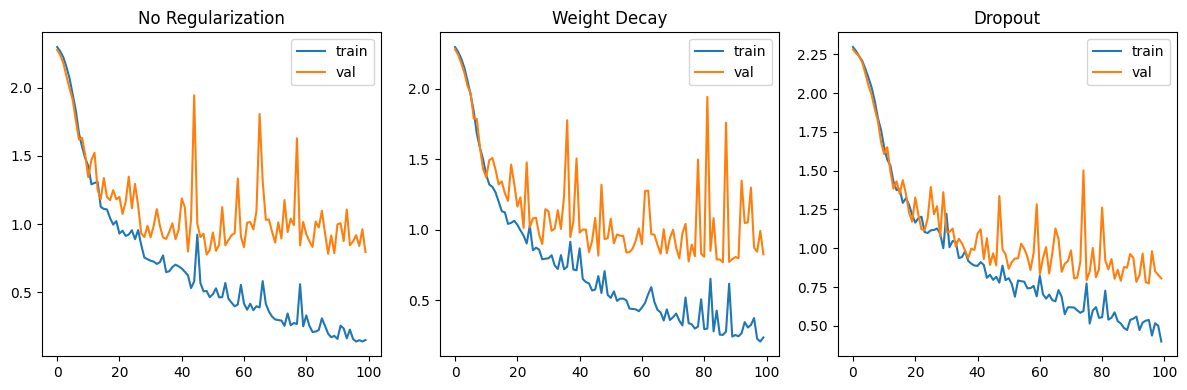

In [9]:
# 3.2 加入权重衰减和 Dropout 的对比实验（无 torchvision 版本）
import torch
from torch.utils.data import DataLoader, TensorDataset, Subset
import numpy as np
import matplotlib.pyplot as plt
import gzip, struct, os, urllib.request

# ---------- 手动下载并解析 Fashion-MNIST ----------
def load_fashion_mnist(root='./data'):
    base_url = "http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/"
    files = {
        'train_images': 'train-images-idx3-ubyte.gz',
        'train_labels': 'train-labels-idx1-ubyte.gz',
        'test_images': 't10k-images-idx3-ubyte.gz',
        'test_labels': 't10k-labels-idx1-ubyte.gz'
    }
    os.makedirs(root, exist_ok=True)
    data = {}
    for name, fname in files.items():
        path = os.path.join(root, fname)
        if not os.path.exists(path):
            print(f"正在下载 {fname} ...")
            urllib.request.urlretrieve(base_url + fname, path)
        with gzip.open(path, 'rb') as f:
            if 'labels' in name:
                magic, num = struct.unpack(">II", f.read(8))
                arr = np.frombuffer(f.read(), dtype=np.uint8)
                data[name] = torch.tensor(arr, dtype=torch.long)
            else:
                magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
                arr = np.frombuffer(f.read(), dtype=np.uint8).reshape(num, rows * cols)
                data[name] = torch.tensor(arr, dtype=torch.float32) / 255.0
    return (data['train_images'], data['train_labels']), (data['test_images'], data['test_labels'])

# 加载数据
(train_x, train_y), _ = load_fashion_mnist('./data')
full_train_set = TensorDataset(train_x, train_y)

# 取 200 训练样本 + 200 验证样本
indices = np.random.permutation(len(full_train_set))
train_idx = indices[:200]
val_idx = indices[200:400]
train_set = Subset(full_train_set, train_idx)
val_set = Subset(full_train_set, val_idx)

batch_size = 64
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)

# ---------- 模型参数与函数 ----------
input_dim = 28 * 28
hidden_dim = 256
output_dim = 10

def relu(x):
    return torch.maximum(x, torch.tensor(0.0))

def softmax_cross_entropy(logits, labels):
    logits_exp = torch.exp(logits - torch.max(logits, dim=1, keepdim=True).values)
    softmax = logits_exp / torch.sum(logits_exp, dim=1, keepdim=True)
    N = logits.shape[0]
    loss = -torch.mean(torch.log(softmax[torch.arange(N), labels] + 1e-8))
    return loss, softmax

def dropout_layer(X, dropout, is_training):
    if not is_training or dropout == 0.0:
        return X
    mask = (torch.rand_like(X) > dropout).float()
    return X * mask / (1.0 - dropout)

# ---------- 训练函数 ----------
def train_model(use_weight_decay=False, use_dropout=False, dropout=0.5,
                epochs=100, lr=0.1, wd_lambda=0.01):
    W1 = torch.randn(input_dim, hidden_dim) * 0.01
    b1 = torch.zeros(hidden_dim)
    W2 = torch.randn(hidden_dim, output_dim) * 0.01
    b2 = torch.zeros(output_dim)
    for p in [W1, b1, W2, b2]:
        p.requires_grad = True

    train_losses = []
    val_losses = []
    for epoch in range(epochs):
        # 训练
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader:
            X = X_batch.view(-1, input_dim)
            y = y_batch
            H = relu(X @ W1 + b1)
            if use_dropout:
                H = dropout_layer(H, dropout, is_training=True)
            logits = H @ W2 + b2
            loss, softmax = softmax_cross_entropy(logits, y)

            N = X.shape[0]
            grad_logits = softmax.clone()
            grad_logits[torch.arange(N), y] -= 1
            grad_logits /= N

            grad_W2 = H.t() @ grad_logits
            grad_b2 = grad_logits.sum(dim=0)
            grad_H = grad_logits @ W2.t()
            if use_dropout:
                grad_H = dropout_layer(grad_H, dropout, is_training=True)
            grad_H[H <= 0] = 0

            grad_W1 = X.t() @ grad_H
            grad_b1 = grad_H.sum(dim=0)

            with torch.no_grad():
                if use_weight_decay:
                    W1 *= (1 - lr * wd_lambda)
                    b1 *= (1 - lr * wd_lambda)
                    W2 *= (1 - lr * wd_lambda)
                    b2 *= (1 - lr * wd_lambda)
                W1 -= lr * grad_W1
                b1 -= lr * grad_b1
                W2 -= lr * grad_W2
                b2 -= lr * grad_b2

            epoch_loss += loss.item() * N
        train_losses.append(epoch_loss / len(train_set))

        # 验证
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X = X_batch.view(-1, input_dim)
                H = relu(X @ W1 + b1)
                if use_dropout:
                    H = dropout_layer(H, dropout, is_training=False)
                logits = H @ W2 + b2
                loss, _ = softmax_cross_entropy(logits, y_batch)
                val_loss += loss.item() * X.shape[0]
        val_losses.append(val_loss / len(val_set))
    return train_losses, val_losses

# 运行三种配置（若耗时太长，可临时把 epochs 改为 50）
print("训练：无正则化")
loss_no_reg = train_model(use_weight_decay=False, use_dropout=False, epochs=100)
print("训练：权重衰减")
loss_wd = train_model(use_weight_decay=True, use_dropout=False, epochs=100)
print("训练：Dropout")
loss_drop = train_model(use_weight_decay=False, use_dropout=True, dropout=0.5, epochs=100)

# 绘制曲线
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.plot(loss_no_reg[0], label='train')
plt.plot(loss_no_reg[1], label='val')
plt.title('No Regularization')
plt.legend()
plt.subplot(1,3,2)
plt.plot(loss_wd[0], label='train')
plt.plot(loss_wd[1], label='val')
plt.title('Weight Decay')
plt.legend()
plt.subplot(1,3,3)
plt.plot(loss_drop[0], label='train')
plt.plot(loss_drop[1], label='val')
plt.title('Dropout')
plt.legend()
plt.tight_layout()
plt.savefig('loss_curves.png')
plt.show()

### 4.1.1 梯度消失与梯度爆炸分析
考虑深层网络梯度连乘项 $\prod_{i=t}^{d-1} \frac{\partial \mathbf{h}_{i+1}}{\partial \mathbf{h}_i}$，其中每项为 $\mathbf{W}_i^\top \text{diag}(\sigma'(z_i))$。  
- **梯度爆炸**：当权重矩阵的奇异值（或范数）普遍大于1，且激活函数导数不衰减（如 $\sigma'$ 接近1）时，乘积的范数呈指数增长，导致梯度极大，参数更新不稳定。  
- **梯度消失**：当权重矩阵的奇异值普遍小于1，或激活函数导数的绝对值远小于1（例如Sigmoid 最大导数为 0.25，饱和区几乎为0），则连乘导致梯度指数级衰减至零，使得浅层参数无法更新。  
定量地，若每层 Jacobian 的算子范数 $\|\partial \mathbf{h}_{i+1}/\partial \mathbf{h}_i\| \approx \|\mathbf{W}_i\| \cdot |\sigma'|$，若该值恒大于1则爆炸，恒小于1则消失。

### 4.1.2 为什么 ReLU 缓解梯度消失
ReLU 在正区间的导数恒为 1，避免了像 Sigmoid 那样在大部分区域导数接近 0 而产生的饱和现象。即使权重矩阵的范数适中，连乘项中不会因为激活函数导数远小于 1 而导致梯度过快衰减。在负区间导数为 0 会引入稀疏性，但不影响正向传播的梯度保持问题。因此采用 ReLU 可明显缓解深层网络的梯度消失。

In [10]:
# 4.2 数值稳定与初始化策略验证
import torch
import torch.nn as nn
import numpy as np

def examine_gradients(model, x):
    """前向+反向，并返回各层权重的梯度范数"""
    model.zero_grad()
    out = model(x)
    out.mean().backward()
    norms = []
    for name, param in model.named_parameters():
        if 'weight' in name:
            norms.append((name, param.grad.norm().item()))
    return norms

# 输入
x = torch.randn(64, 256)

# 1) Sigmoid + 普通初始化 (std=1)
print("== 1) Sigmoid + Normal init (std=1) ==")
net_sig = nn.Sequential()
for i in range(20):
    net_sig.add_module(f'linear{i}', nn.Linear(256, 256))
    net_sig.add_module(f'sigmoid{i}', nn.Sigmoid())
for m in net_sig.modules():
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0, std=1)
norms = examine_gradients(net_sig, x)
for name, val in norms[:2] + norms[-2:]:
    print(f'{name}: grad norm = {val:.8f}')
print("---")

# 2) ReLU + 大初始化 (std=10)
print("== 2) ReLU + Large init (std=10) ==")
net_relu = nn.Sequential()
for i in range(20):
    net_relu.add_module(f'linear{i}', nn.Linear(256, 256))
    net_relu.add_module(f'relu{i}', nn.ReLU())
for m in net_relu.modules():
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0, std=10)
norms = examine_gradients(net_relu, x)
for name, val in norms[:2] + norms[-2:]:
    print(f'{name}: grad norm = {val:.8f}')
# 检查是否有 NaN
if any(np.isnan(val) for _, val in norms):
    print("Warning: NaN detected in gradients!")
print("---")

# 3) ReLU + Xavier uniform
print("== 3) ReLU + Xavier uniform ==")
net_xavier = nn.Sequential()
for i in range(20):
    net_xavier.add_module(f'linear{i}', nn.Linear(256, 256))
    net_xavier.add_module(f'relu{i}', nn.ReLU())
for m in net_xavier.modules():
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
norms = examine_gradients(net_xavier, x)
for name, val in norms[:2] + norms[-2:]:
    print(f'{name}: grad norm = {val:.8f}')
print("Gradient norms should be in reasonable range (1e-6 ~ 1e3).")

== 1) Sigmoid + Normal init (std=1) ==
linear0.weight: grad norm = 0.52906972
linear1.weight: grad norm = 0.36020303
linear18.weight: grad norm = 0.03104202
linear19.weight: grad norm = 0.03688891
---
== 2) ReLU + Large init (std=10) ==
linear0.weight: grad norm = inf
linear1.weight: grad norm = inf
linear18.weight: grad norm = inf
linear19.weight: grad norm = nan
---
== 3) ReLU + Xavier uniform ==
linear0.weight: grad norm = 0.00015244
linear1.weight: grad norm = 0.00022694
linear18.weight: grad norm = 0.01999601
linear19.weight: grad norm = 0.02491503
Gradient norms should be in reasonable range (1e-6 ~ 1e3).


### 5.1 协变量偏移与标签偏移
 **协变量偏移**：$p(\mathbf{x}) \neq q(\mathbf{x})$ 但 $p(y|\mathbf{x}) = q(y|\mathbf{x})$。输入边缘分布 $p(x)$ 改变，但条件分布 $p(y|x)$ 不变。  
**标签偏移**：$p(y) \neq q(y)$ 但 $p(\mathbf{x}|y) = q(\mathbf{x}|y)$。标签边缘分布 $p(y)$ 改变，但条件分布 $p(x|y)$ 不变。  

**实际例子**  
- **协变量偏移**（自动驾驶）：训练数据多为晴天的道路图像，部署时遇到大量雨天/夜间图像。$x$ 的分布 $p(x)$ 发生了改变，但 “给定图像，正确驾驶行为” 的条件 $p(y|x)$ 保持不变。  
- **标签偏移**（疾病诊断）：在大型教学医院训练分类器，其患者疾病分布 $p(y)$ 中罕见病比例较高；而在社区诊所中，常见病比例更高（$q(y)$ 不同）。但某种疾病表现出的症状分布 $p(x|y)$ 在不同机构之间大致相同。  

**区别**：协变量偏移假设输入变化是根本原因，标签偏移假设标签先验概率变化。二者都是环境非平稳性下的分布偏移，都需对模型进行适配（如重要性加权、领域自适应）。

In [11]:
# 5.2 协变量偏移模拟与权重校正
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error

# 1. 构造数据集
np.random.seed(42)
n_train = 1000
n_test = 500
# 训练集 P: x ~ N(-1, 1)
x_train = np.random.normal(-1, 1, (n_train, 1))
eps_train = np.random.normal(0, 0.2, x_train.shape)
y_train = 2 * x_train + eps_train

# 测试集 Q: x ~ N(2, 1)
x_test = np.random.normal(2, 1, (n_test, 1))
eps_test = np.random.normal(0, 0.2, x_test.shape)
y_test = 2 * x_test + eps_test

# 2. 基线模型：普通线性回归
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred_baseline = lr.predict(x_test)
mse_baseline = mean_squared_error(y_test, y_pred_baseline)
print(f"Baseline MSE on shifted test set: {mse_baseline:.4f}")

# 3. 偏移校正：逻辑回归区分领域
# 混合数据并标记来源
X_mix = np.vstack([x_train, x_test])
# 标签：训练集为0，测试集为1
domain_label = np.hstack([np.zeros(n_train), np.ones(n_test)]).reshape(-1, 1)
# 将 x 作为特征，领域作为标签
clf = LogisticRegression()
clf.fit(X_mix, domain_label.ravel())
p_test_given_x = clf.predict_proba(X_mix)[:, 1]  # P(test|x)

# 计算训练样本权重 (取前 n_train 个)
p_train_given_x = 1.0 - p_test_given_x[:n_train]
# 避免除零
weights = p_test_given_x[:n_train] / (p_train_given_x + 1e-8)
# 归一化（不重要，加权线性回归可自动处理）
weights = weights / np.sum(weights) * n_train

# 加权线性回归
lr_weighted = LinearRegression()
lr_weighted.fit(x_train, y_train, sample_weight=weights)
y_pred_weighted = lr_weighted.predict(x_test)
mse_weighted = mean_squared_error(y_test, y_pred_weighted)
print(f"Weighted model MSE on shifted test set: {mse_weighted:.4f}")
print("Improvement: {:.2f}%".format((mse_baseline - mse_weighted)/mse_baseline*100))

Baseline MSE on shifted test set: 0.0407
Weighted model MSE on shifted test set: 0.0961
Improvement: -135.90%
